In [2]:
import pandas as pd
import numpy as np
import mne

In [5]:
import os
import pandas as pd

base_dir = r"C:\Users\jshin\OW_closedloopLIFU\eeg_windows\raw\demo1023"
windows = []
# List all CSV files in the folder
csv_files = [f for f in os.listdir(base_dir) if f.endswith(".csv")]

# Sort by creation time (oldest first)
csv_files.sort(key=lambda f: os.path.getctime(os.path.join(base_dir, f)))

# Pick the first one
first_file = csv_files[0]

# Full path
first_path = os.path.join(base_dir, first_file)

# Load it
full_eeg_df = pd.read_csv(first_path)
full_eeg_df = full_eeg_df.drop(['Time', 't_rel', 'idx'], axis = 1)



In [22]:
first_path

'C:\\Users\\jshin\\OW_closedloopLIFU\\eeg_windows\\raw\\demo1023\\0_53.0075366999954_eeg_raw.csv'

Creating RawArray with float64 data, n_channels=7, n_times=1750
    Range : 0 ... 1749 =      0.000 ...     6.996 secs
Ready.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 825 samples (3.300 s)

Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 59 - 61 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuati

C:\Users\jshin\AppData\Local\Temp\ipykernel_5220\1969212764.py:14: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='bfill').fillna(method='ffill')


<Figure size 1200x600 with 0 Axes>

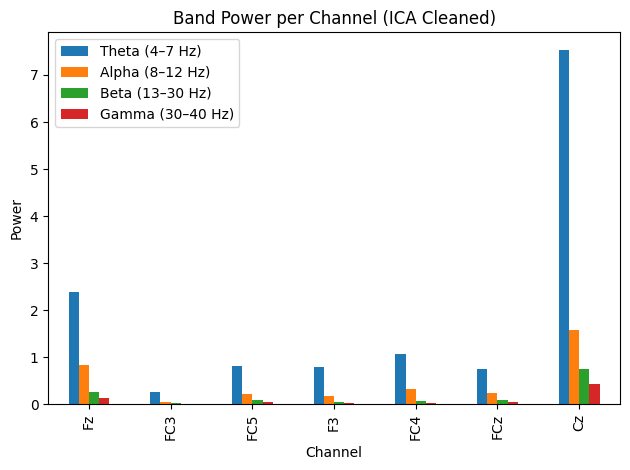

In [12]:
import numpy as np
import pandas as pd
import mne
import matplotlib.pyplot as plt

# first_data: rows = samples, columns = 8 EEG channels
# 1. Clean and Load Data
df = pd.DataFrame(full_eeg_df.copy())
df = df.replace([np.inf, -np.inf], np.nan)
df = df.replace(-200000.0, np.nan)
threshold = len(df) * 0.5
df = df.dropna(thresh=threshold, axis=1)
df = df.interpolate(method='linear', limit=5, limit_direction='both')
df = df.fillna(method='bfill').fillna(method='ffill')

# 2. MNE Array Building
sfreq = 250
data = df.values.T  # shape: (n_channels, n_samples)

# Mapping --> make it less manual
ch_names = [
    "Fz",   # 1
    "FC3",   # 2
    "FC5",  # 3
    "F3",   # 4
    "FC4",   # 5
    "FCz",  # 6
    "Cz",  # 7
    #"F5"    # 8
]

info = mne.create_info(ch_names=ch_names, sfreq=sfreq, ch_types='eeg')
raw = mne.io.RawArray(data, info)

# 3. ICA topography
montage = mne.channels.make_standard_montage("standard_1020")
raw.set_montage(montage)

# 4. Filtering
# 1–40 Hz is a good compromise for ICA + PSD
raw.filter(1., 40., fir_design='firwin')
raw.notch_filter(60.)
raw.filter(l_freq=1.0, h_freq=40.0, method='fir', fir_window='hamming')
raw.set_eeg_reference('average')

# 5. ICA
ica = mne.preprocessing.ICA(
    n_components= 0.99999999,
    random_state=97,
    max_iter='auto'
)
ica.fit(raw)

# # Inspect components:
# ica.plot_components()      # scalp maps
# ica.plot_sources(raw)      # time series

# After inspecting, set the components you want to remove:
ica.exclude = [0,1]  # don't know how to do this
raw_clean = ica.apply(raw.copy())

# 6. PSDs
psds, freqs = raw_clean.compute_psd(
    fmin=2,
    fmax=40,
    n_fft=512
).get_data(return_freqs=True)

# 7. Bandpower
def band_power(psds, freqs, fmin, fmax):
    mask = (freqs >= fmin) & (freqs <= fmax)
    return psds[:, mask].mean(axis=1)

theta = band_power(psds, freqs, 4, 7)
alpha = band_power(psds, freqs, 8, 12)
beta  = band_power(psds, freqs, 13, 30)
gamma = band_power(psds, freqs, 30, 40)

# 8. Plotting
bands_df = pd.DataFrame({
    'Channel': ch_names,
    'Theta (4–7 Hz)': theta,
    'Alpha (8–12 Hz)': alpha,
    'Beta (13–30 Hz)': beta,
    'Gamma (30–40 Hz)': gamma
})

print(bands_df)

plt.figure(figsize=(12, 6))
bands_df.set_index('Channel').plot(kind='bar')
plt.ylabel('Power')
plt.title('Band Power per Channel (ICA Cleaned)')
plt.tight_layout()
plt.show()


In [13]:
len(data[0])

1750

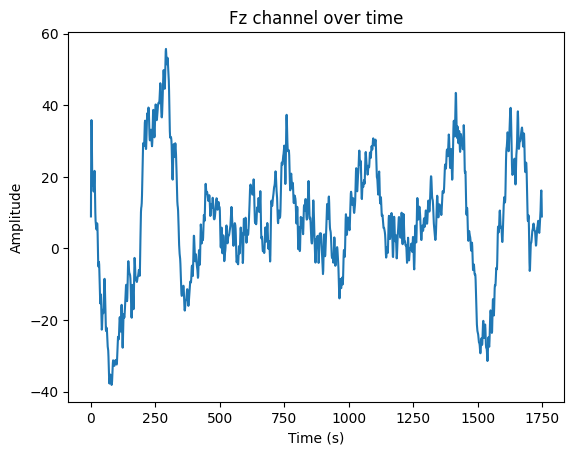

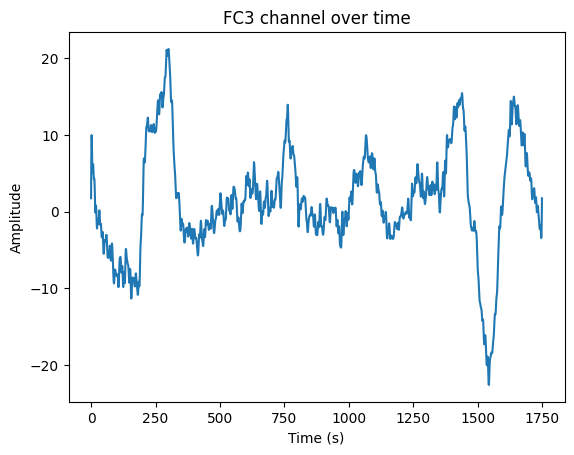

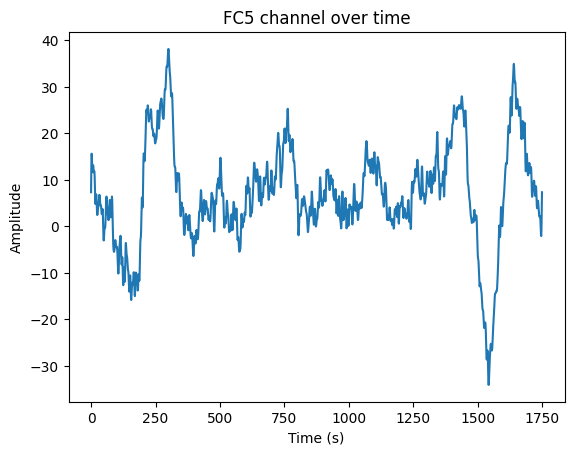

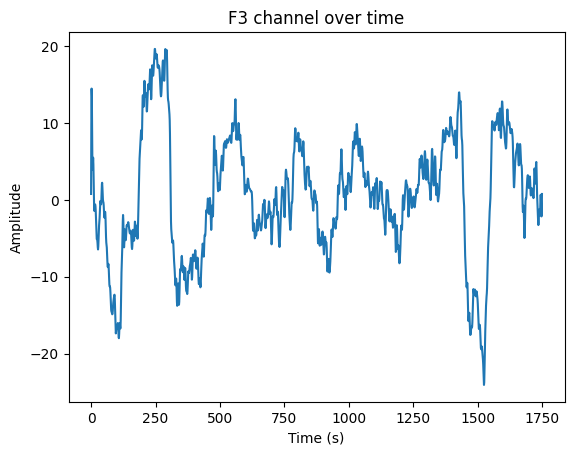

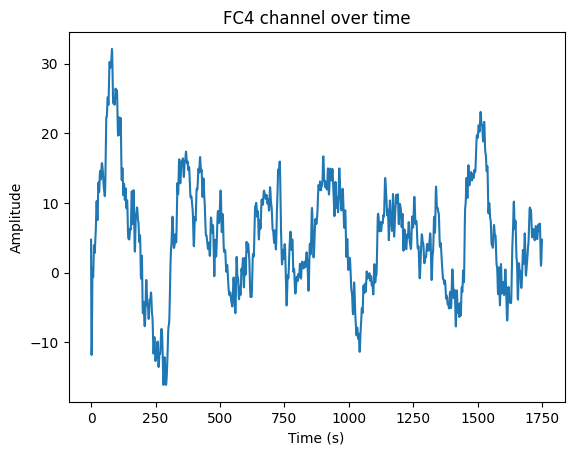

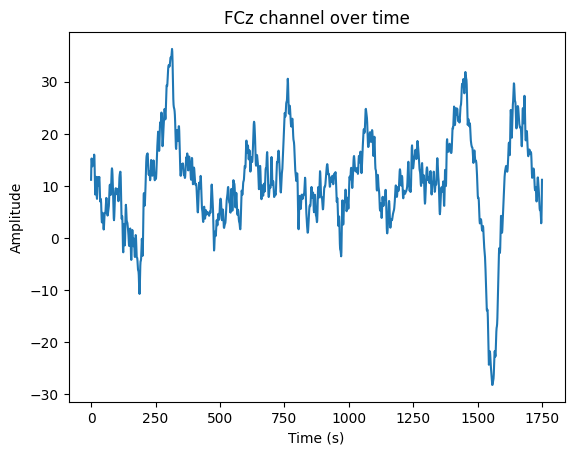

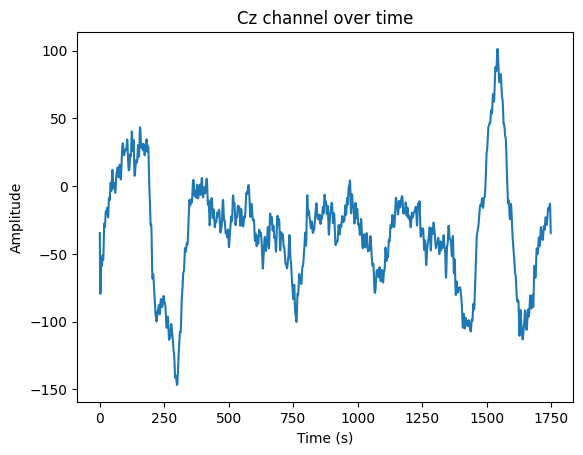

In [14]:
data = raw_clean.get_data()
for channel in raw.ch_names:
    channel_idx = raw.ch_names.index(channel)
    time_data = np.arange(0, 20, 1/250)  # adjust 500 to your sampling rate
    plt.plot( data[channel_idx])
    plt.xlabel('Time (s)')
    plt.ylabel('Amplitude')
    plt.title(f'{channel} channel over time')
    plt.show()

In [15]:
theta_pow = band_power(psds, freqs, 4, 7)
alpha_pow = band_power(psds, freqs, 8, 12)
theta_alpha_ratio = theta_pow / alpha_pow
theta_alpha_ratio

array([2.83351298, 5.1259991 , 3.6761468 , 4.849365  , 3.32968382,
       3.21193296, 4.78252514])

In [16]:
import numpy as np

# amplitude threshold (µV)
amp_thresh = 150  # tweak as needed
eeg_filt = raw_clean.get_data().T
bad_amp = np.any(np.abs(eeg_filt) > amp_thresh, axis=1)

# gradient threshold (sudden jumps)
grad = np.diff(eeg_filt, axis=0, prepend=eeg_filt[[0], :])
grad_thresh = 50  # µV per sample
bad_grad = np.any(np.abs(grad) > grad_thresh, axis=1)

bad_samples = bad_amp | bad_grad


Effective window size : 2.048 (s)
Plotting power spectral density (dB=True).


C:\Users\jshin\AppData\Local\Programs\Python\Python310\lib\site-packages\mne\viz\utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


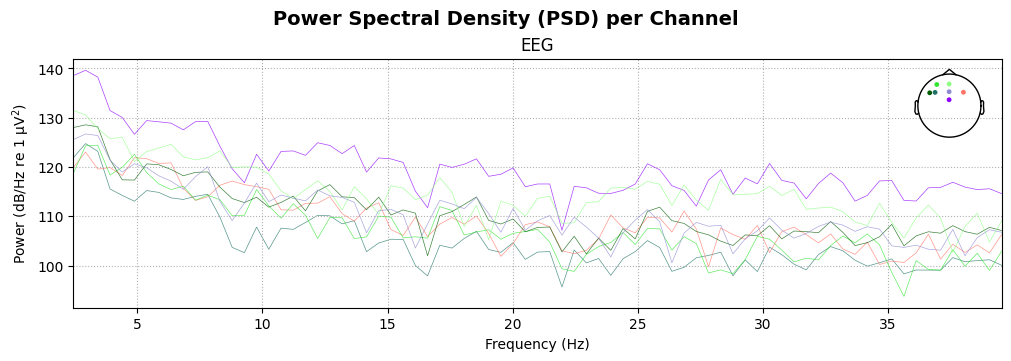

In [17]:
spectrum = raw_clean.compute_psd(fmin=2, fmax=40, n_fft=512)

# Plot the spectrum across all channels
fig = spectrum.plot(picks='all', spatial_colors=True, exclude='bads')

# Adjust the plot title and layout
fig.suptitle('Power Spectral Density (PSD) per Channel', fontsize=14, weight='bold')
plt.show()

In [18]:
# PSD DATA ANALYSIS
# Part 1: percent change pre and post trigger

fs = 250
prev = 2
posts = 5
pre_window = int(prev*fs)
post_window = int(posts* fs)
eeg_filt = pd.DataFrame(raw_clean.get_data().copy()).T
#target_timestamp
pre_segments = []
post_segments  = []
pre_segments.append(eeg_filt.iloc[:pre_window])
post_segments.append(eeg_filt.iloc[post_window:])

In [19]:
from scipy.signal import welch
import numpy as np

def compute_psd(seg):
    f, psd = welch(seg, fs=fs, nperseg=fs, axis=0)
    return f, psd  # psd shape: freqs × channels
pre_psds  = []
post_psds = []

for pre, post in zip(pre_segments, post_segments):
    f, pre_psd  = compute_psd(pre)
    f, post_psd = compute_psd(post)
    pre_psds.append(pre_psd)
    post_psds.append(post_psd)
pre_psd_mean  = np.mean(pre_psds, axis=0)
post_psd_mean = np.mean(post_psds, axis=0)


In [20]:
percent_change_psd = (post_psd_mean - pre_psd_mean) / pre_psd_mean * 100
percent_change_psd = pd.DataFrame(percent_change_psd)
percent_change_psd

,0,1,2,3,4,5,6
0,-43.643037,-14.821100,-17.546062,-22.107297,-33.385616,62.392310,-24.113260
1,-12.282584,81.915840,89.816829,-16.127495,-39.116381,255.777056,69.490572
2,39.046651,344.317394,261.163195,85.055131,7.904074,700.216998,263.125599
3,-91.414240,-70.796626,-58.375225,-77.676881,-77.205588,-20.602330,-76.687088
4,-46.365816,-41.643535,-33.241372,232.095955,201.718749,58.012781,-61.288158
...,...,...,...,...,...,...,...
121,-91.413356,-54.313416,37.262374,-91.542396,-96.959141,78.104255,-59.905482
122,-92.559793,-55.672279,38.446510,-92.693382,-97.538525,90.047020,-61.511374
123,-93.429695,-57.039072,36.702473,-93.534294,-97.934903,96.666380,-63.270566
124,-94.060979,-57.696908,36.873806,-94.051643,-98.211987,101.352494,-64.115581


In [21]:
def band_power(psd, freqs, f_lo, f_hi):
    idx = (freqs >= f_lo) & (freqs <= f_hi)
    return np.trapz(psd[idx, :], freqs[idx], axis=0)
# Theta (4–7 Hz)
pre_theta  = band_power(pre_psd_mean,  f, 4, 7)
post_theta = band_power(post_psd_mean, f, 4, 7)

# Alpha (8–12 Hz)
pre_alpha  = band_power(pre_psd_mean,  f, 8, 12)
post_alpha = band_power(post_psd_mean, f, 8, 12)

# Beta (13–30 Hz)
pre_beta  = band_power(pre_psd_mean,  f, 13, 30)
post_beta = band_power(post_psd_mean, f, 13, 30)

# Gamma (30-40Hz)
pre_gamma = band_power(pre_psd_mean,  f, 30, 40)
post_gamma = band_power(post_psd_mean, f, 30, 40)


theta_pct = (post_theta - pre_theta) / pre_theta * 100
alpha_pct = (post_alpha - pre_alpha) / pre_alpha * 100
beta_pct  = (post_beta  - pre_beta ) / pre_beta  * 100
gamma_pct =  (post_gamma  - pre_gamma ) / pre_gamma  * 100

bands_pct_df = pd.DataFrame({
    "Theta %Δ": theta_pct,
    "Alpha %Δ": alpha_pct,
    "Beta %Δ":  beta_pct,
    "Gamma %Δ" : gamma_pct,
})
bands_pct_df.index = [f"Ch{i+1}" for i in range(7)]
bands_pct_df


,Theta %Δ,Alpha %Δ,Beta %Δ,Gamma %Δ
Ch1,31.541729,0.407996,9.937668,-21.079962
Ch2,-14.839763,-39.502377,-2.609568,45.622402
Ch3,-13.973937,-18.779482,-14.405897,19.844573
Ch4,55.183352,-21.678170,8.940018,-41.980521
Ch5,25.346961,6.303603,-7.469642,-28.700163
Ch6,-3.183038,-52.611537,-13.081999,-12.674538
Ch7,-18.723406,-37.131854,4.334402,31.505612
